**[IMDb](https://www.imdb.com/interfaces/):**
Contains the following information for titles:
tconst (string) - alphanumeric unique identifier of the title

*   titleType (string) – the type/format of the title (e.g. movie, short, tvseries, tvepisode, video, etc)
*   primaryTitle (string) – the more popular title / the title used by the filmmakers on promotional materials at the point of release
*   originalTitle (string) - original title, in the original language
*   isAdult (boolean) - 0: non-adult title; 1: adult title
*   startYear (YYYY) – represents the release year of a title. In the case of TV Series, it is the series start year
*   endYear (YYYY) – TV Series end year. ‘\N’ for all other title types
*   runtimeMinutes – primary runtime of the title, in minutes
genres (string array) – includes up to three genres associated with the title

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import gzip
import shutil
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

%matplotlib inline
np.random.seed(1)
warnings.filterwarnings('ignore', 'Maximum number of iteration reached before convergence.*') #Sem isso aqui ele fica falando pra aumentar o max_iter
warnings.filterwarnings('ignore', 'Liblinear failed to converge, increase the number of iterations.*') #Sem isso aqui ele fica falando pra aumentar o max_iter
warnings.filterwarnings('ignore', 'Warm-start fitting without increasing n_estimators does not fit new trees.*') #Sem isso aqui ele fica falando pra aumentar o max_iter

**Processo de download automático dos dados**

In [2]:
!gdown --id '1gW_nq6La78KAcg1G8ABIQ0v0-_yE8I64'

Downloading...
From: https://drive.google.com/uc?id=1gW_nq6La78KAcg1G8ABIQ0v0-_yE8I64
To: /content/title.basics.tsv.gz
100% 149M/149M [00:01<00:00, 117MB/s]


In [3]:
with gzip.open('title.basics.tsv.gz', 'rb') as f_in:
    with open('title.basics.txt', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

**Tratamento de dados**

In [4]:
df_imdb = pd.read_csv('title.basics.txt', sep='\t')

/usr/local/lib/python3.7/dist-packages/IPython/core/interactiveshell.py:2718: DtypeWarning: Columns (4,5) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


In [5]:
df_imdb

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0000001,short,Carmencita,Carmencita,0,1894,\N,1,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892,\N,5,"Animation,Short"
2,tt0000003,short,Pauvre Pierrot,Pauvre Pierrot,0,1892,\N,4,"Animation,Comedy,Romance"
3,tt0000004,short,Un bon bock,Un bon bock,0,1892,\N,12,"Animation,Short"
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893,\N,1,"Comedy,Short"
...,...,...,...,...,...,...,...,...,...
8524816,tt9916848,tvEpisode,Episode #3.17,Episode #3.17,0,2010,\N,\N,"Action,Drama,Family"
8524817,tt9916850,tvEpisode,Episode #3.19,Episode #3.19,0,2010,\N,\N,"Action,Drama,Family"
8524818,tt9916852,tvEpisode,Episode #3.20,Episode #3.20,0,2010,\N,\N,"Action,Drama,Family"
8524819,tt9916856,short,The Wind,The Wind,0,2015,\N,27,Short


In [6]:
df_imdb.isna().sum()

tconst             0
titleType          0
primaryTitle       9
originalTitle      9
isAdult            0
startYear          0
endYear            0
runtimeMinutes     0
genres            10
dtype: int64

In [7]:
df_imdb.isnull().sum()

tconst             0
titleType          0
primaryTitle       9
originalTitle      9
isAdult            0
startYear          0
endYear            0
runtimeMinutes     0
genres            10
dtype: int64

In [8]:
df_imdb.dropna(axis=0, how='any',inplace=True)

In [9]:
df_imdb = df_imdb.drop(columns=['tconst'])

In [10]:
df_imdb = df_imdb.drop(columns=['startYear'])

In [11]:
df_imdb = df_imdb.drop(columns=['endYear'])

In [12]:
df_imdb = df_imdb.drop(columns=['originalTitle'])

In [13]:
df_imdb = df_imdb.drop(columns=['runtimeMinutes'])

In [14]:
df_imdb.dtypes

titleType       object
primaryTitle    object
isAdult         object
genres          object
dtype: object

In [15]:
df_imdb[df_imdb['titleType'] == "\\N"].shape[0]

0

In [16]:
df_imdb[df_imdb['primaryTitle'] == "\\N"].shape[0]

0

In [17]:
df_imdb[df_imdb['isAdult'] == "\\N"].shape[0]

0

In [18]:
df_imdb[df_imdb['genres'] == "\\N"].shape[0]

396499

In [19]:
df_imdb['titleType'].unique()

array(['short', 'movie', 'tvEpisode', 'tvSeries', 'tvShort', 'tvMovie',
       'tvMiniSeries', 'tvSpecial', 'video', 'videoGame', 'tvPilot'],
      dtype=object)

In [20]:
df_tvSeries = df_imdb[df_imdb['titleType'] == 'tvSeries']
df_tvSeries = df_tvSeries.reset_index()
df_tvSeries = df_tvSeries.drop(columns=['index'])

In [21]:
generos = df_tvSeries.genres.str.get_dummies(sep=',')
df_tvSeries = pd.concat([df_tvSeries, generos], axis=1)
df_tvSeries = df_tvSeries.drop(columns=['genres'])

In [22]:
df_tvSeries

,titleType,primaryTitle,isAdult,Action,Adult,Adventure,Animation,Biography,Comedy,Crime,Documentary,Drama,Family,Fantasy,Film-Noir,Game-Show,History,Horror,Music,Musical,Mystery,News,Reality-TV,Romance,Sci-Fi,Short,Sport,Talk-Show,Thriller,War,Western,\N
0,tvSeries,Les Misérables,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,tvSeries,Voice of Firestone Televues,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,tvSeries,The German Weekly Review,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3,tvSeries,You Are an Artist,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,tvSeries,Americana,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218017,tvSeries,Rumpole of the Bailey,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
218018,tvSeries,Kalyanam Mudhal Kadhal Varai,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
218019,tvSeries,Lost in Food,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
218020,tvSeries,Meie aasta Aafrikas,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [23]:
df_movie = df_imdb[df_imdb['titleType'] == 'movie']
df_movie = df_movie.reset_index()
df_movie = df_movie.drop(columns=['index'])

In [24]:
generos = df_movie.genres.str.get_dummies(sep=',')
df_movie = pd.concat([df_movie, generos], axis=1)
df_movie = df_movie.drop(columns=['genres'])

In [25]:
df_movie

,titleType,primaryTitle,isAdult,Action,Adult,Adventure,Animation,Biography,Comedy,Crime,Documentary,Drama,Family,Fantasy,Film-Noir,Game-Show,History,Horror,Music,Musical,Mystery,News,Reality-TV,Romance,Sci-Fi,Short,Sport,Talk-Show,Thriller,War,Western,\N
0,movie,Bohemios,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,movie,The Story of the Kelly Gang,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,movie,The Prodigal Son,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,movie,Robbery Under Arms,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,movie,Hamlet,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
596853,movie,Rodolpho Teóphilo - O Legado de um Pioneiro,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
596854,movie,De la ilusión al desconcierto: cine colombiano...,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
596855,movie,Dankyavar Danka,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
596856,movie,6 Gunn,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [26]:
df_videoGame = df_imdb[df_imdb['titleType'] == 'videoGame']
df_videoGame = df_videoGame.reset_index()
df_videoGame = df_videoGame.drop(columns=['index'])

In [27]:
generos = df_videoGame.genres.str.get_dummies(sep=',')
df_videoGame = pd.concat([df_videoGame, generos], axis=1)
df_videoGame = df_videoGame.drop(columns=['genres'])

In [28]:
df_videoGame

,titleType,primaryTitle,isAdult,Action,Adult,Adventure,Animation,Biography,Comedy,Crime,Documentary,Drama,Family,Fantasy,Game-Show,History,Horror,Music,Musical,Mystery,News,Reality-TV,Romance,Sci-Fi,Short,Sport,Talk-Show,Thriller,War,Western,\N
0,videoGame,"MysteryDisc: Murder, Anyone?",0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1,videoGame,MysteryDisc: Many Roads to Murder,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2,videoGame,Night Trap,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
3,videoGame,Gabriel Knight: Sins of the Fathers,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,videoGame,King's Quest VII: The Princeless Bride,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29941,videoGame,Brain Age Express: Math,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
29942,videoGame,Brain Age Express: Arts & Letters,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
29943,videoGame,Brain Age Express: Sudoku,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
29944,videoGame,Aero Dancing F,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


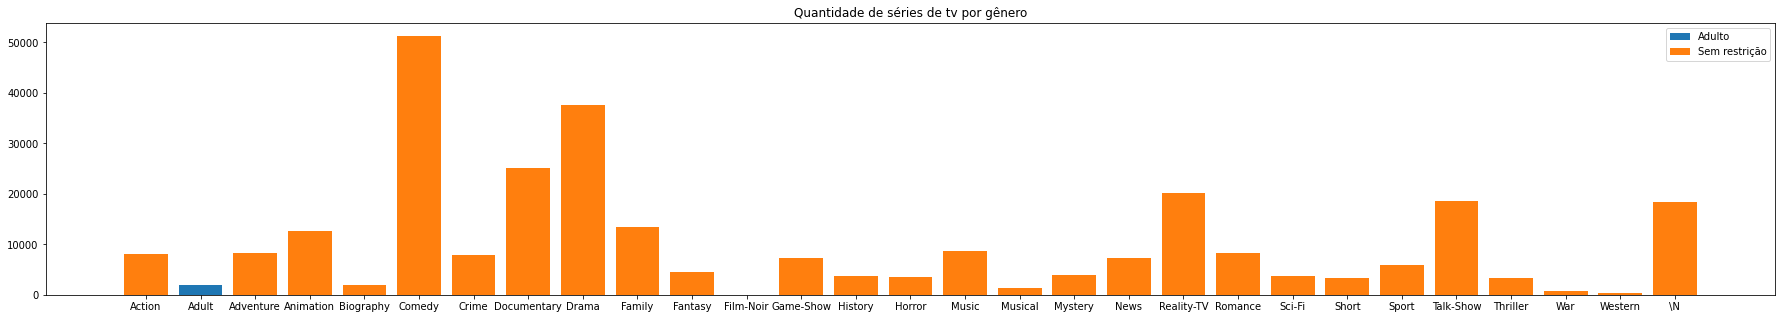

In [29]:
plt.figure(figsize=(31,5))
plt.bar(df_tvSeries.iloc[:,3:].columns.array, df_tvSeries[df_tvSeries['isAdult']  == 1].iloc[:,3:].sum().array)
plt.bar(df_tvSeries.iloc[:,3:].columns.array, df_tvSeries[df_tvSeries['isAdult']  == 0].iloc[:,3:].sum().array, bottom = df_tvSeries[df_tvSeries['isAdult']  == 1].iloc[:,3:].sum().array)
plt.legend(['Adulto', 'Sem restrição'])
plt.title('Quantidade de séries de tv por gênero')
plt.show()

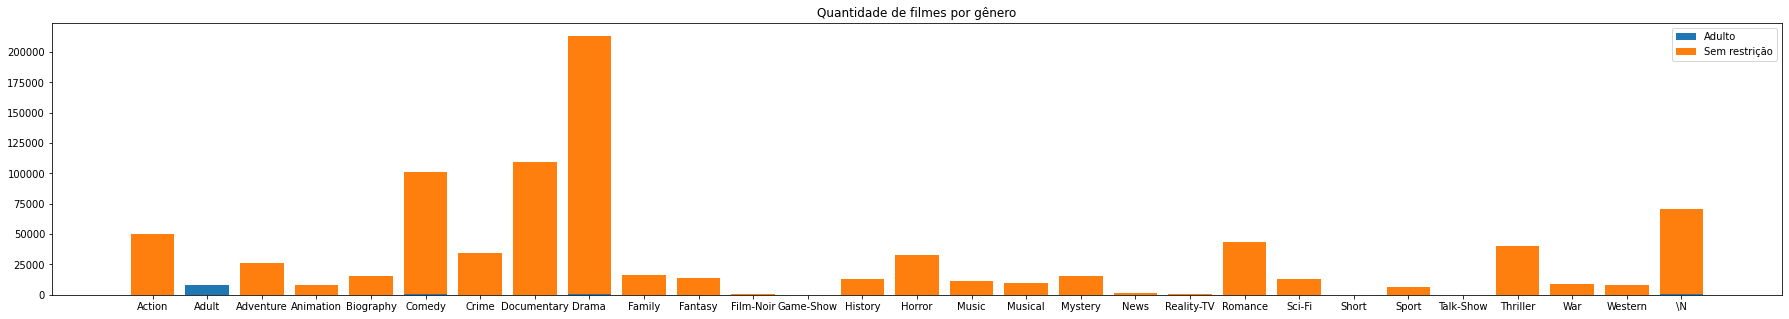

In [30]:
plt.figure(figsize=(31,5))
plt.bar(df_movie.iloc[:,3:].columns.array, df_movie[df_movie['isAdult']  == 1].iloc[:,3:].sum().array)
plt.bar(df_movie.iloc[:,3:].columns.array, df_movie[df_movie['isAdult']  == 0].iloc[:,3:].sum().array, bottom = df_movie[df_movie['isAdult']  == 1].iloc[:,3:].sum().array)
plt.legend(['Adulto', 'Sem restrição'])
plt.title('Quantidade de filmes por gênero')
plt.show()

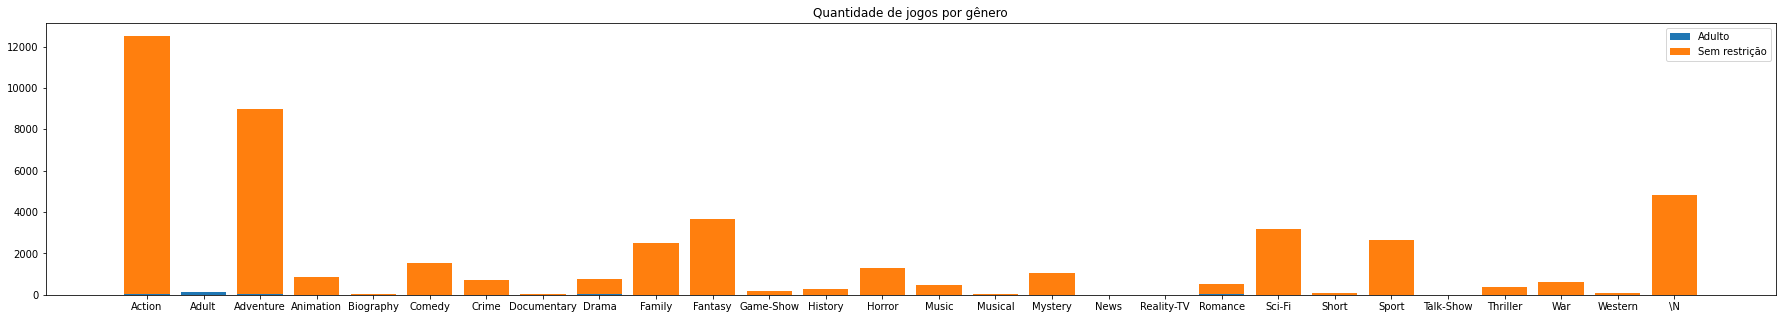

In [31]:
plt.figure(figsize=(31,5))
plt.bar(df_videoGame.iloc[:,3:].columns.array, df_videoGame[df_videoGame['isAdult']  == 1].iloc[:,3:].sum().array)
plt.bar(df_videoGame.iloc[:,3:].columns.array, df_videoGame[df_videoGame['isAdult']  == 0].iloc[:,3:].sum().array, bottom = df_videoGame[df_videoGame['isAdult']  == 1].iloc[:,3:].sum().array)
plt.legend(['Adulto', 'Sem restrição'])
plt.title('Quantidade de jogos por gênero')
plt.show()

In [32]:
df_tvSeries.shape[0]

218022

In [33]:
df_tvSeries[df_tvSeries['isAdult']  == 1].shape[0]

1920

In [34]:
df_tvSeries[df_tvSeries['isAdult']  == 0].shape[0]

214713

In [35]:
[df_tvSeries[df_tvSeries['isAdult']  == 0].shape[0],df_movie[df_movie['isAdult']  == 0].shape[0],df_videoGame[df_videoGame['isAdult']  == 0].shape[0]]

[214713, 585067, 29634]

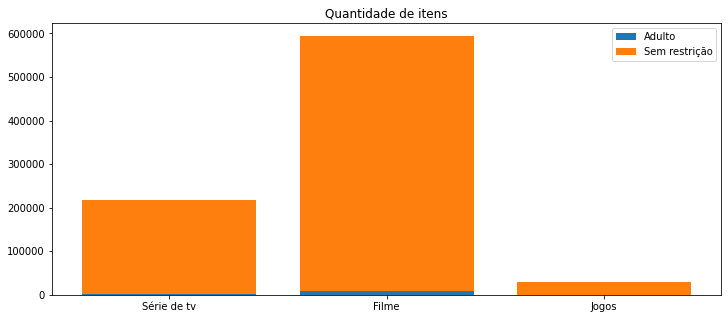

In [36]:
plt.figure(figsize=(12,5))
plt.bar(['Série de tv','Filme','Jogos'], [df_tvSeries[df_tvSeries['isAdult']  == 1].shape[0],df_movie[df_movie['isAdult']  == 1].shape[0],df_videoGame[df_videoGame['isAdult']  == 1].shape[0]])
plt.bar(['Série de tv','Filme','Jogos'], [df_tvSeries[df_tvSeries['isAdult']  == 0].shape[0],df_movie[df_movie['isAdult']  == 0].shape[0],df_videoGame[df_videoGame['isAdult']  == 0].shape[0]], bottom = [df_tvSeries[df_tvSeries['isAdult']  == 1].shape[0],df_movie[df_movie['isAdult']  == 1].shape[0],df_videoGame[df_videoGame['isAdult']  == 1].shape[0]])
plt.legend(['Adulto', 'Sem restrição'])
plt.title('Quantidade de itens')
plt.show()

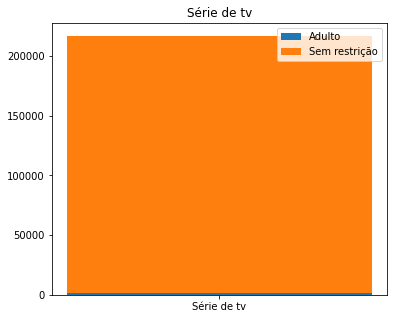

In [37]:
plt.figure(figsize=(6,5))
plt.bar(['Série de tv'], [df_tvSeries[df_tvSeries['isAdult']  == 1].shape[0]])
plt.bar(['Série de tv'], [df_tvSeries[df_tvSeries['isAdult']  == 0].shape[0]], bottom = [df_tvSeries[df_tvSeries['isAdult']  == 1].shape[0]])
plt.legend(['Adulto', 'Sem restrição'])
plt.title('Série de tv')
plt.show()

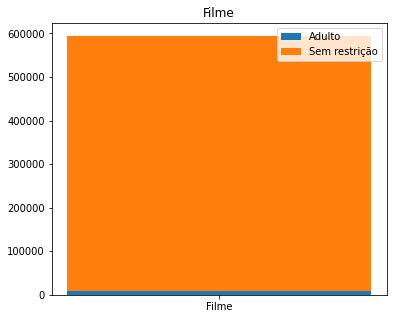

In [38]:
plt.figure(figsize=(6,5))
plt.bar(['Filme'], [df_movie[df_movie['isAdult']  == 1].shape[0]])
plt.bar(['Filme'], [df_movie[df_movie['isAdult']  == 0].shape[0]], bottom = [df_movie[df_movie['isAdult']  == 1].shape[0]])
plt.legend(['Adulto', 'Sem restrição'])
plt.title('Filme')
plt.show()

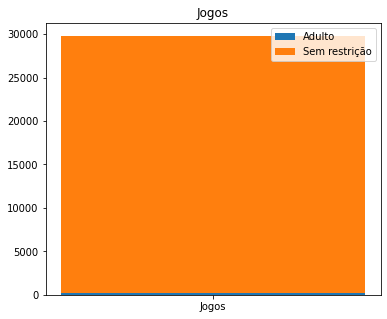

In [39]:
plt.figure(figsize=(6,5))
plt.bar(['Jogos'], [df_videoGame[df_videoGame['isAdult']  == 1].shape[0]])
plt.bar(['Jogos'], [df_videoGame[df_videoGame['isAdult']  == 0].shape[0]], bottom = [df_videoGame[df_videoGame['isAdult']  == 1].shape[0]])
plt.legend(['Adulto', 'Sem restrição'])
plt.title('Jogos')
plt.show()

In [40]:
def curvaCotovelo(generos_escalados,nome,n):
  SSE = []
  for cluster in range(1,n):
    kmeans = KMeans(n_clusters = cluster, init='k-means++')
    kmeans.fit(generos_escalados)
    SSE.append(kmeans.inertia_)

  frame = pd.DataFrame({'Cluster':range(1,n), 'SSE':SSE})
  plt.figure(figsize=(12,6))
  plt.plot(frame['Cluster'], frame['SSE'], marker='o')
  plt.xlabel('Número de cluster')
  plt.ylabel('SSE')
  plt.title(f'Curva do cotovelo - {nome}')
  plt.show()

In [41]:
def executarModelo(modelo, df, generos_escalados):
  modelo.fit(generos_escalados)
  grupos = pd.DataFrame(modelo.cluster_centers_,columns=df.iloc[:,2:].columns.array)

  return grupos

In [42]:
def graficoSubPlot(grupos,cluster):
  grupos.transpose().plot.bar(subplots=True,figsize=(35, 5*cluster),sharex=False,rot=0)

In [43]:
def graficoCluster(generos_escalados,modelo,cluster,n):
  tsne = TSNE(n_components=2, perplexity=40, n_iter=n)
  visualizacao = tsne.fit_transform(generos_escalados)
  sns.set(rc={'figure.figsize': (13, 13)})
  sns.scatterplot(x=visualizacao[:, 0],y=visualizacao[:, 1],hue=modelo.labels_,palette=sns.color_palette('hls',cluster))

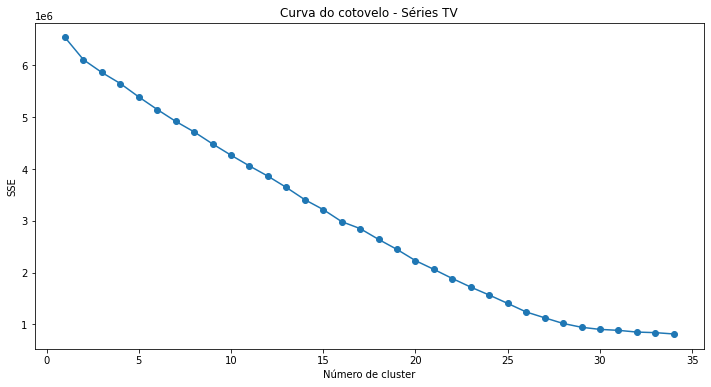

In [44]:
escala = StandardScaler()
generos_escalados = escala.fit_transform(df_tvSeries.iloc[:,2:])
curvaCotovelo(generos_escalados,'Séries TV',35)

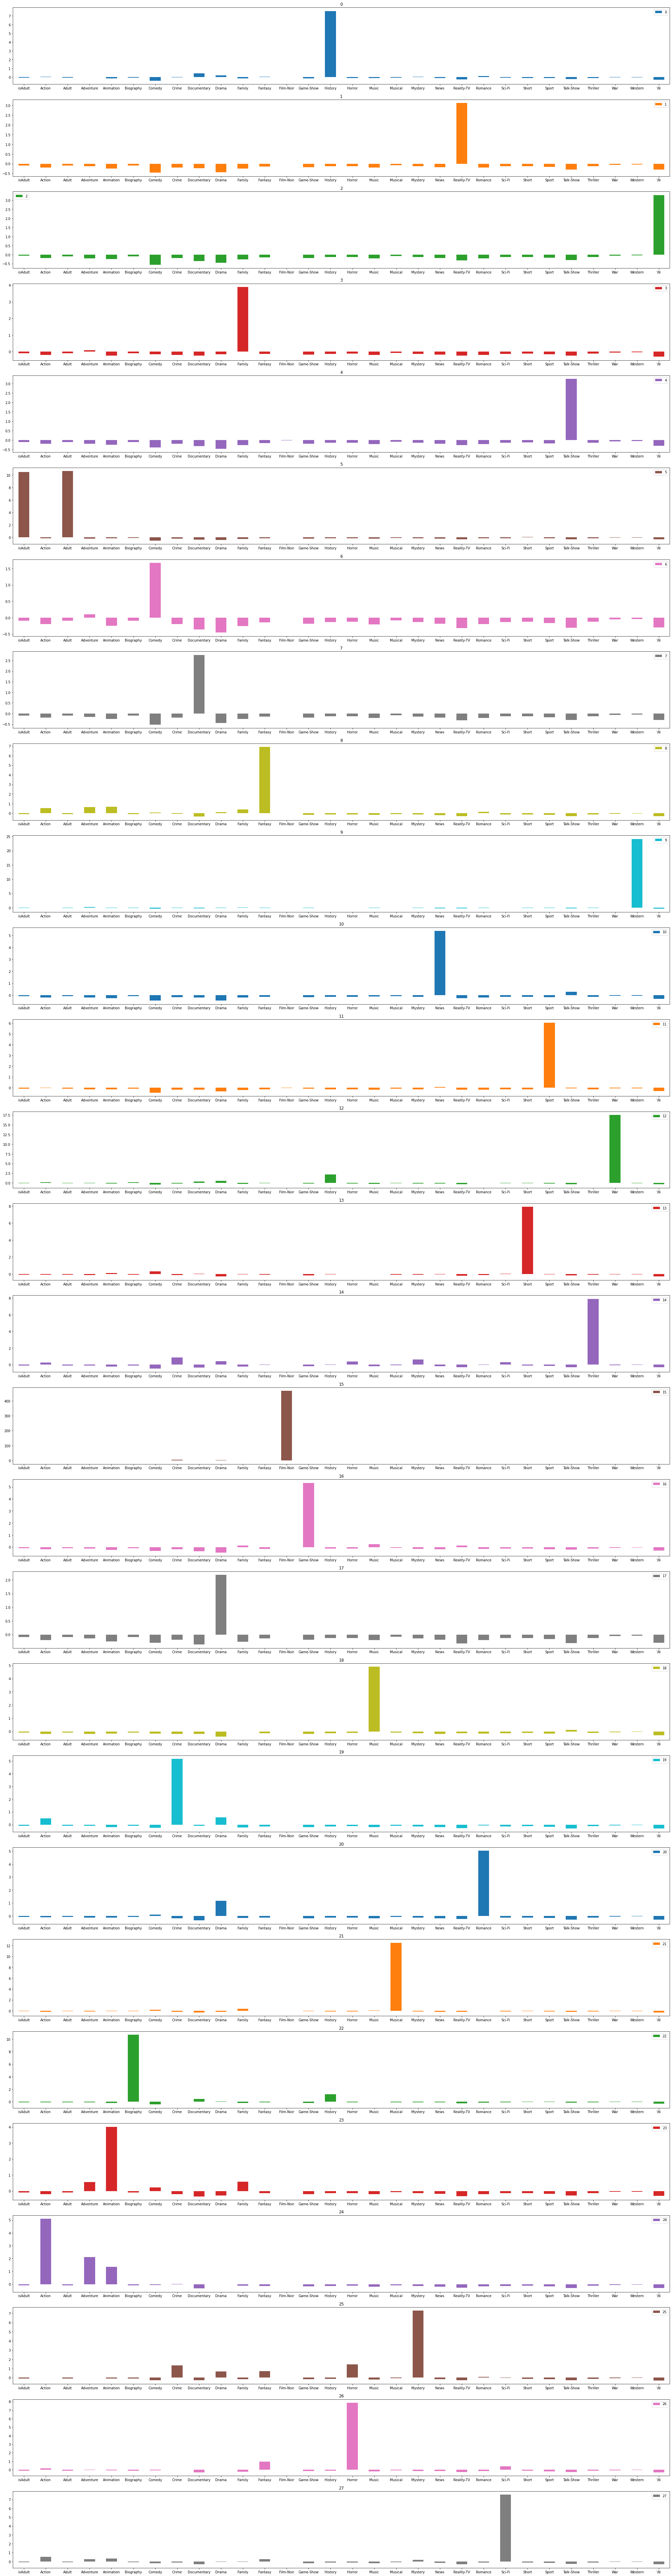

In [45]:
cluster = 28
modelo = KMeans(n_clusters = cluster, init='k-means++')
grupos = executarModelo(modelo, df_tvSeries,generos_escalados)
graficoSubPlot(grupos,cluster)

/usr/local/lib/python3.7/dist-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/usr/local/lib/python3.7/dist-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


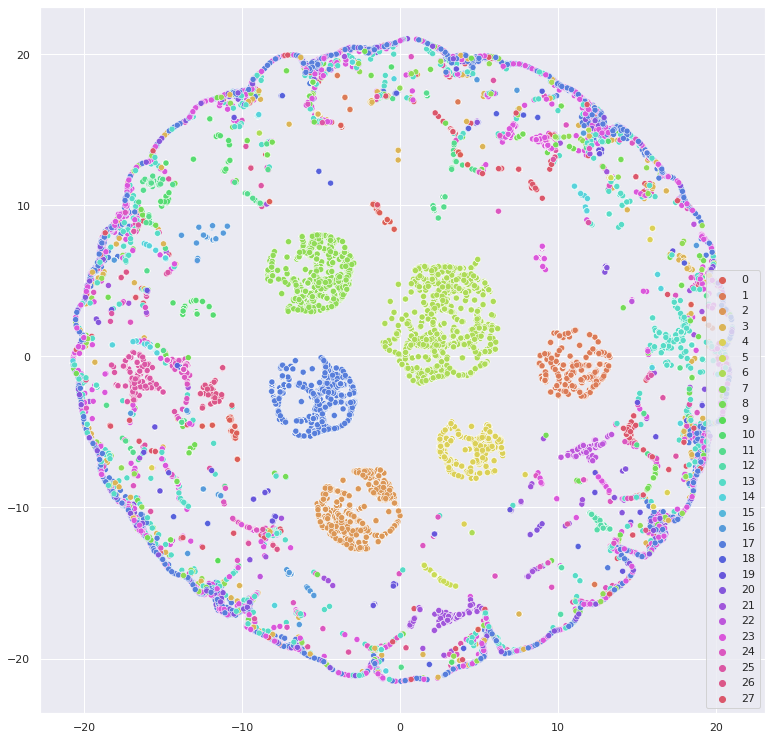

In [46]:
graficoCluster(generos_escalados,modelo,cluster,700)

In [47]:
print(f'Coeficiente de silhueta do modelo com {cluster} cluster é {round(silhouette_score(generos_escalados, modelo.labels_, metric="euclidean")*100,2)}%.')

Coeficiente de silhueta do modelo com 28 cluster é 73.24%.


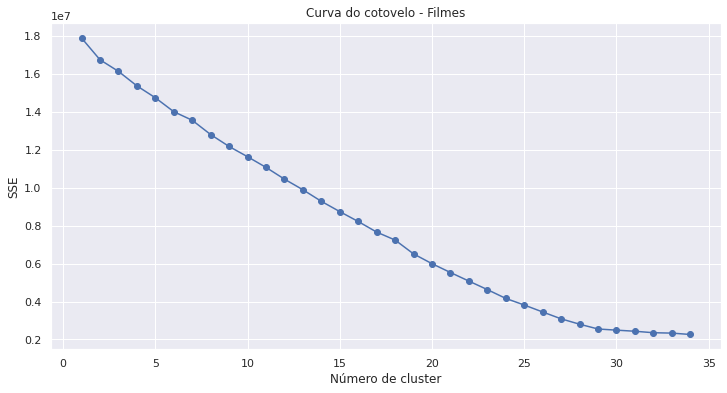

In [48]:
escala = StandardScaler()
generos_escalados = escala.fit_transform(df_movie.iloc[:,2:])
curvaCotovelo(generos_escalados,'Filmes',35)

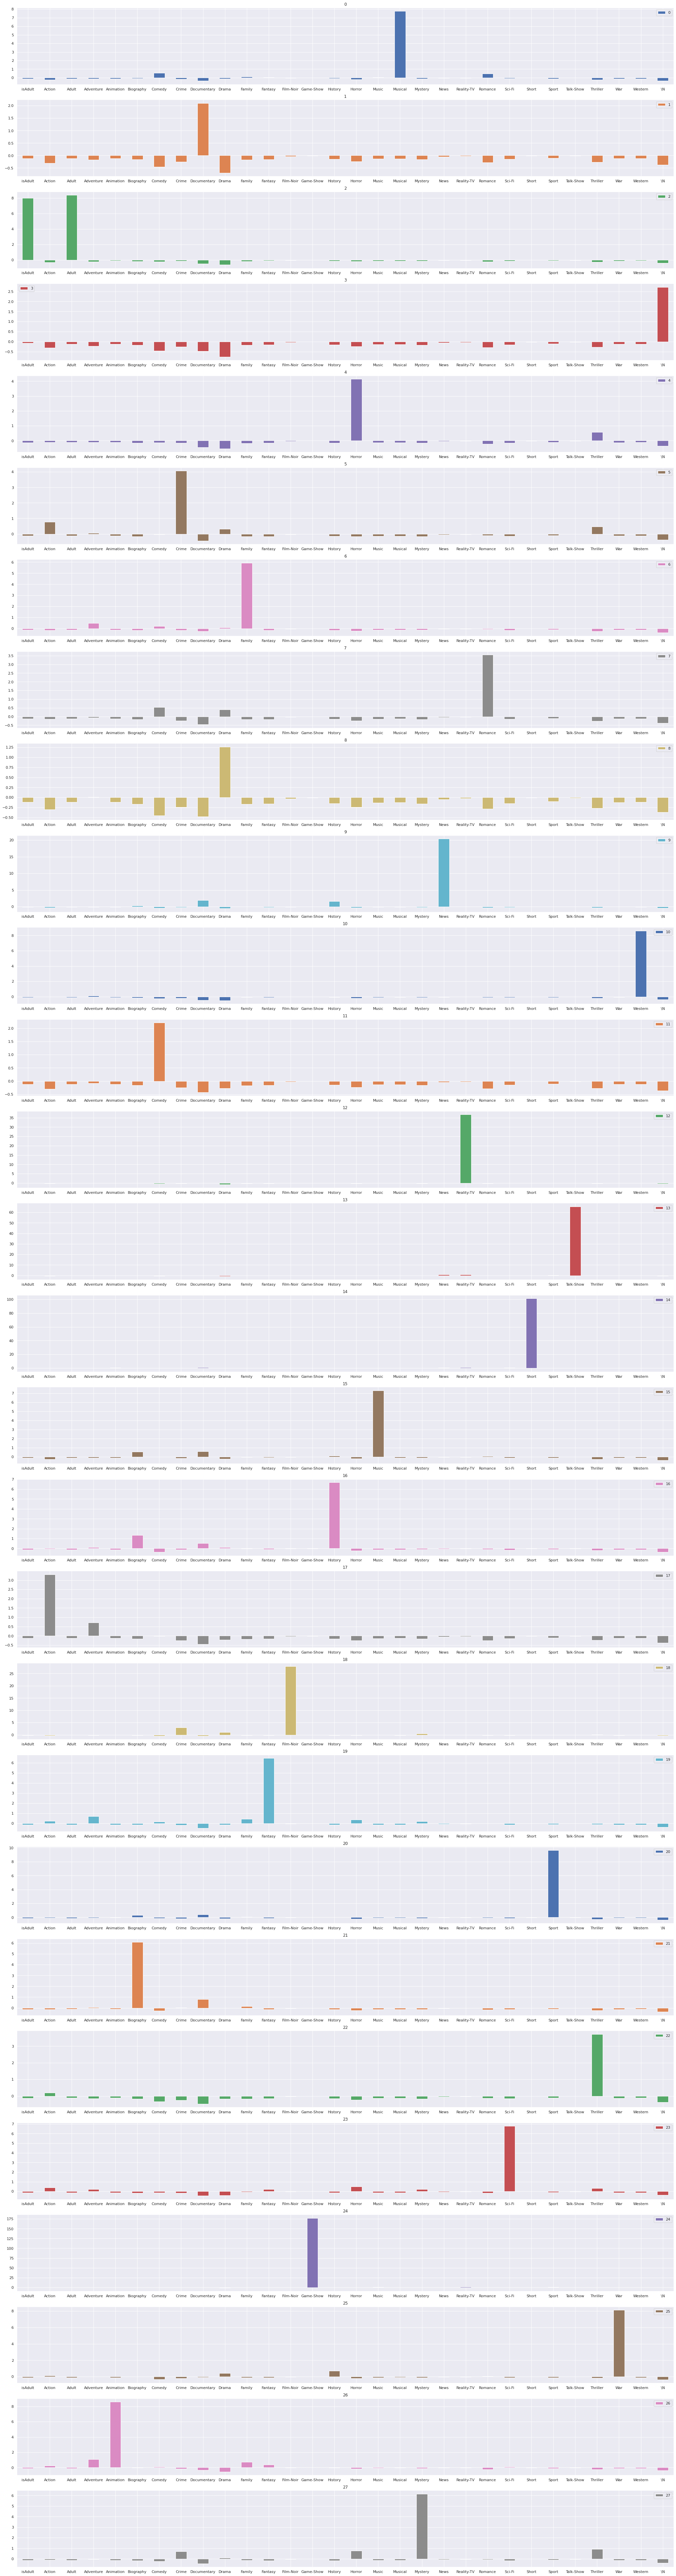

In [49]:
cluster = 28
modelo = KMeans(n_clusters = cluster, init='k-means++')
grupos = executarModelo(modelo, df_movie,generos_escalados)
graficoSubPlot(grupos,cluster)

/usr/local/lib/python3.7/dist-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/usr/local/lib/python3.7/dist-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,
/usr/local/lib/python3.7/dist-packages/google/colab/_event_manager.py:28: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/usr/local/lib/python3.7/dist-packages/IPython/core/pylabtools.py:125: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


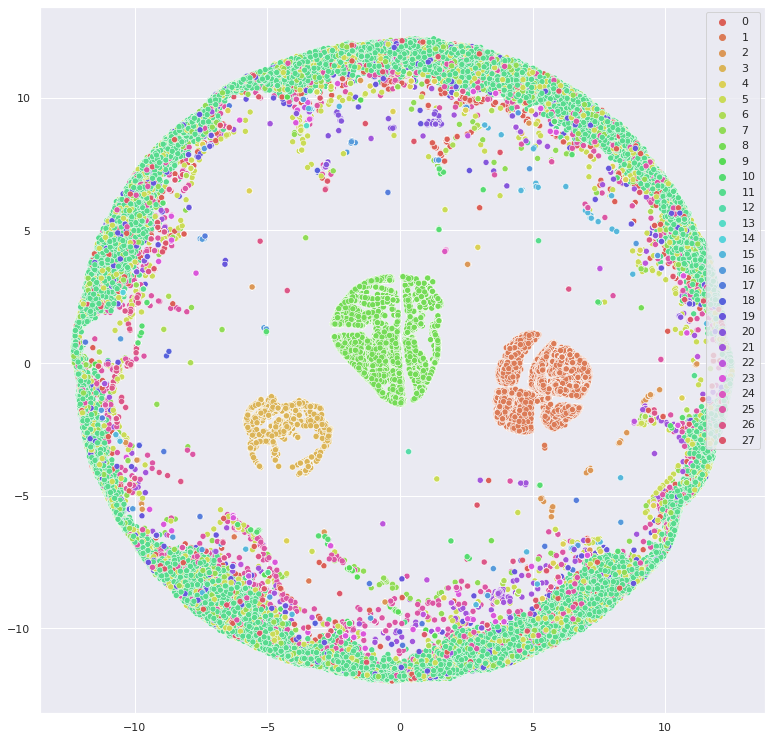

In [50]:
graficoCluster(generos_escalados,modelo,cluster,700)

In [51]:
print(f'Coeficiente de silhueta do modelo com {cluster} cluster é {round(silhouette_score(generos_escalados, modelo.labels_, metric="euclidean")*100,2)}%.')

Coeficiente de silhueta do modelo com 28 cluster é 68.93%.


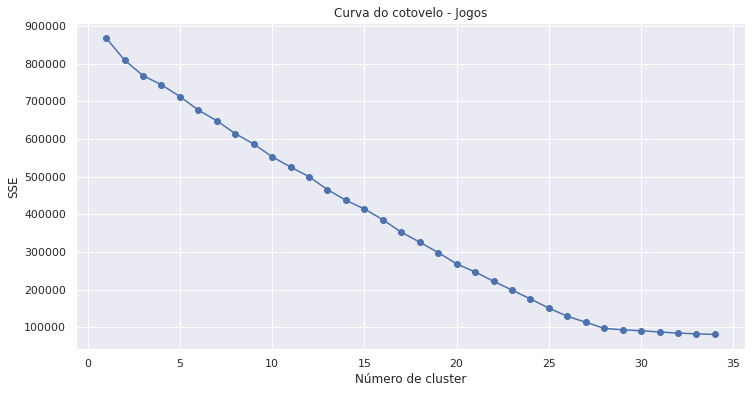

In [52]:
escala = StandardScaler()
generos_escalados = escala.fit_transform(df_videoGame.iloc[:,2:])
curvaCotovelo(generos_escalados,'Jogos',35)

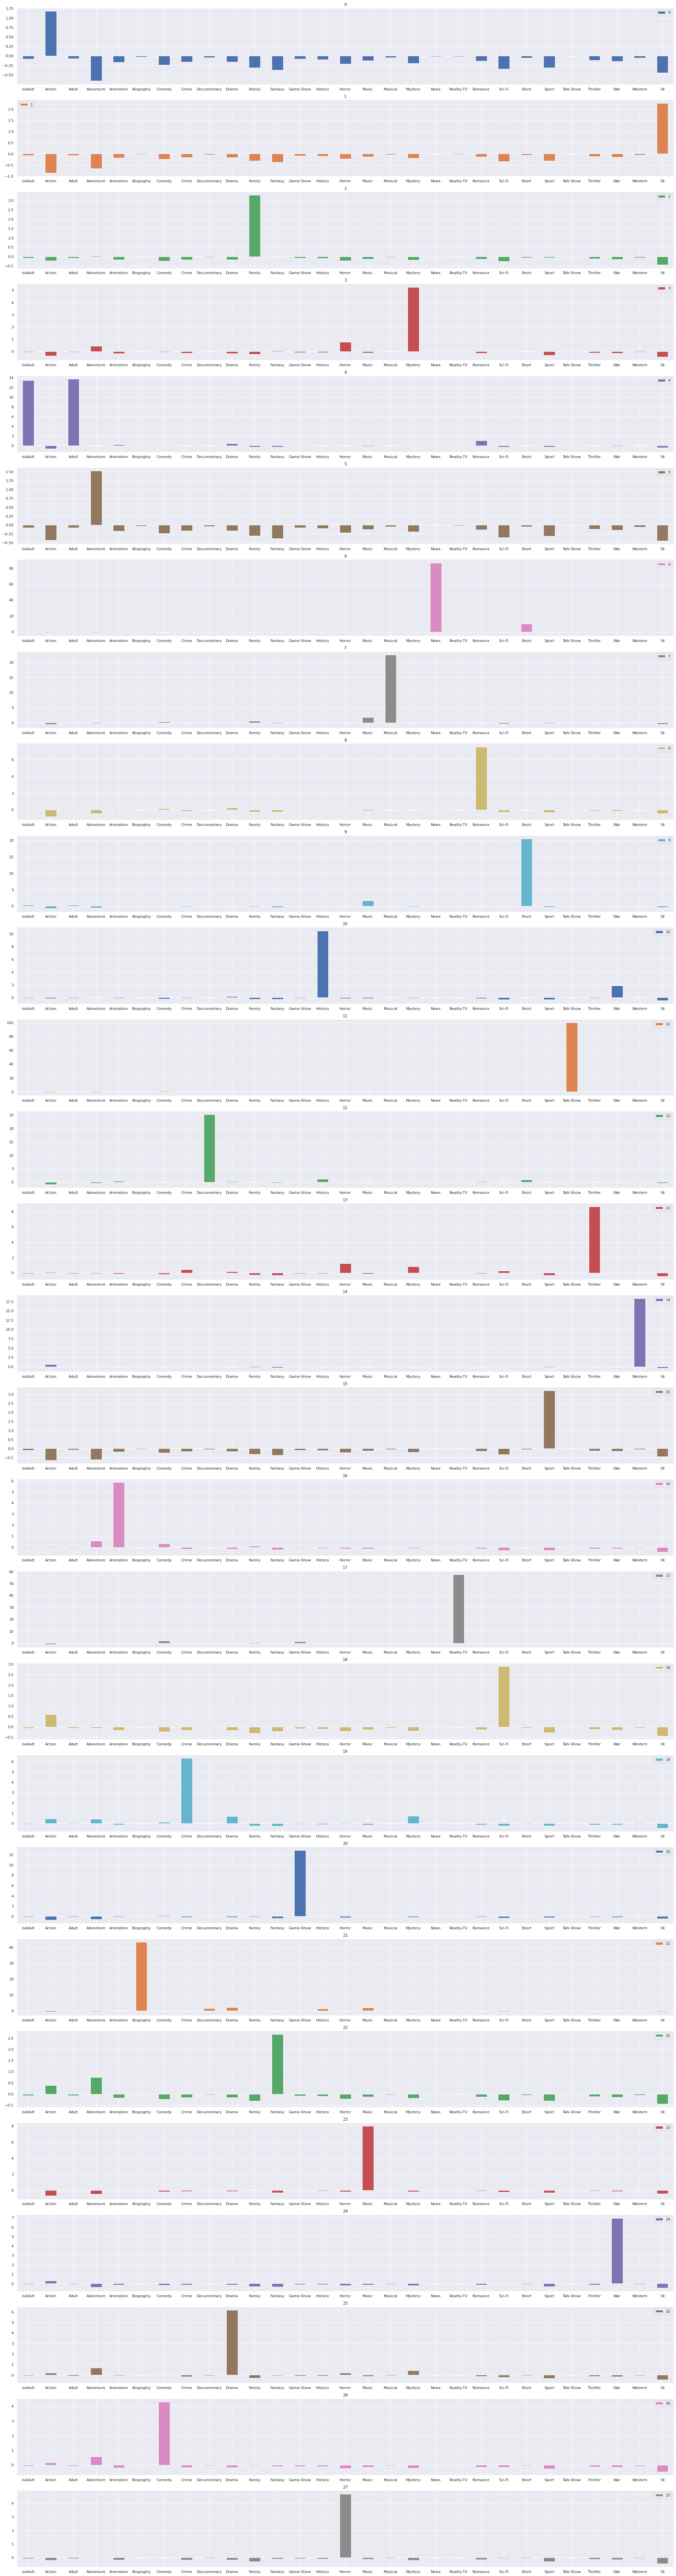

In [53]:
cluster = 28
modelo = KMeans(n_clusters = cluster, init='k-means++')
grupos = executarModelo(modelo, df_videoGame,generos_escalados)
graficoSubPlot(grupos,cluster)

/usr/local/lib/python3.7/dist-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/usr/local/lib/python3.7/dist-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


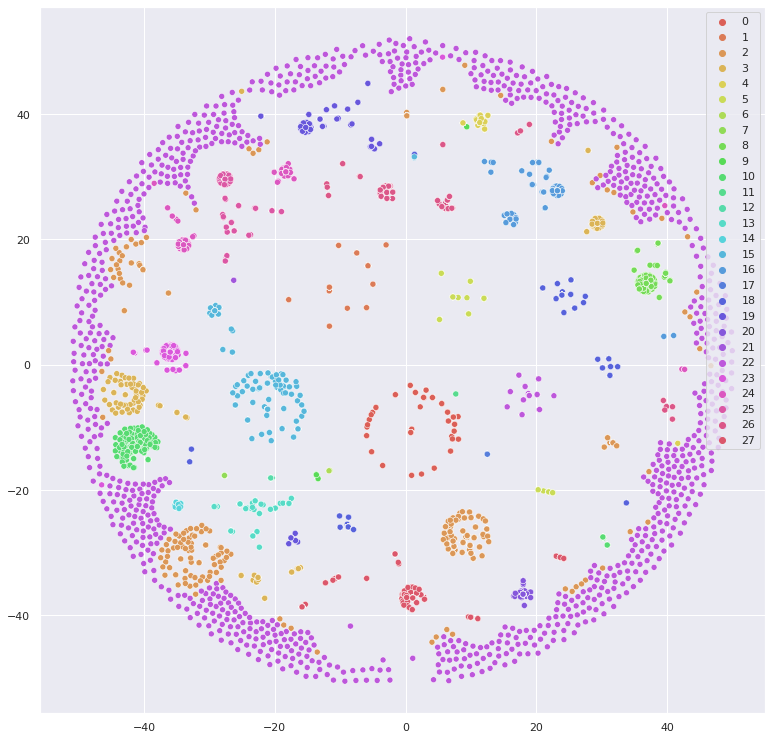

In [54]:
graficoCluster(generos_escalados,modelo,cluster,700)

In [55]:
print(f'Coeficiente de silhueta do modelo com {cluster} cluster é {round(silhouette_score(generos_escalados, modelo.labels_, metric="euclidean")*100,2)}%.')

Coeficiente de silhueta do modelo com 28 cluster é 71.04%.
